In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# Global Configuration Parameters
WINDOW_SIZE = 500
STEP_SIZE = 100
BATCH_SIZE = 128
NUM_CLASSES = 10
TEST_SIZE = 0.10
VAL_SIZE = 0.10
RANDOM_STATE = 42
EPOCHS = 80

LABELED_DIR = Path("./filtered/csv_labeled").resolve()

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# Paths
LABELED_DIR = Path("../filtered/csv_labeled").resolve()
PROCESSED_DIR = Path("../processed_data").resolve()

def load_single_subject_split(
    labeled_dir: Path,
    target_file_idx=0,  # 0 means the 1st person, 1 means the 2nd person, etc.
    window_size=500,
    step_size=100,
    val_size=0.10,
    test_size=0.10,
    random_state=42,
):
    all_files = sorted(labeled_dir.glob("*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {labeled_dir}")
    
    # Ensure the requested index exists
    if target_file_idx >= len(all_files):
        raise ValueError(f"Index {target_file_idx} out of range. Only found {len(all_files)} files.")

    # Target exactly ONE person's file
    file_path = all_files[target_file_idx]
    print(f"🎯 Target Subject Selected: {file_path.name} (Index: {target_file_idx})")

    X_all, y_all = [], []

    # Read the single person's file
    df = pd.read_csv(file_path, header=None)
    data = df.values.copy()

    # ✅ Per-channel z-score normalization for THIS person specifically
    for ch in range(4):
        ch_signal = data[:, ch].astype(np.float64)
        data[:, ch] = (ch_signal - ch_signal.mean()) / (ch_signal.std() + 1e-8)

    # Windowing — only keep pure-label windows for this person
    num_windows = (len(data) - window_size) // step_size + 1
    for i in range(num_windows):
        start = i * step_size
        end   = start + window_size

        window_labels = data[start:end, 4]
        if len(np.unique(window_labels)) != 1:
            continue

        X_all.append(data[start:end, 0:4].astype(np.float32))
        y_all.append(int(data[start, 4]))

    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int64)

    if X_all.size == 0:
        raise ValueError(f"No pure windows could be extracted from {file_path.name}.")

    # Adjust indexing if labels start at 1
    if y_all.min() == 1:
        y_all -= 1

    # ✅ Random shuffle split for this individual person's windows
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(X_all))
    X_all = X_all[indices]
    y_all = y_all[indices]

    n_total = len(X_all)
    n_test  = int(n_total * test_size)
    n_val   = int(n_total * val_size)
    n_train = n_total - n_val - n_test

    # Slice out the individual train, validation, and test arrays
    X_train = X_all[:n_train]
    y_train = y_all[:n_train]
    X_val   = X_all[n_train:n_train + n_val]
    y_val   = y_all[n_train:n_train + n_val]
    X_test  = X_all[n_train + n_val:]
    y_test  = y_all[n_train + n_val:]

    print(f"\n--- Single Subject Split Summary ({file_path.name}) ---")
    print(f"X_train shape : {X_train.shape}")
    print(f"X_val shape   : {X_val.shape}")
    print(f"X_test shape  : {X_test.shape}")
    print(f"Train gesture dist : {dict(sorted(Counter(y_train.tolist()).items()))}")

    return X_train, y_train, X_val, y_val, X_test, y_test, file_path.stem


# Run preprocessing for index 0 (Change target_file_idx to pick a different person)
X_train, y_train, X_val, y_val, X_test, y_test, subject_name = load_single_subject_split(
    LABELED_DIR,
    target_file_idx=0, 
    window_size=500,
    step_size=100,
    val_size=0.10,
    test_size=0.10,
    random_state=42,
)

# Save to a completely unique filename so your mixed-subject data remains untouched!
print("\n--- Saving Isolated Subject Data to Disk ---")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
save_path = PROCESSED_DIR / f"single_{subject_name}_data.npz"

np.savez_compressed(
    save_path,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
)

print(f"✅ Isolated data successfully packed and saved to: {save_path}")
print(f"💾 File size on disk: {save_path.stat().st_size / (1024 * 1024):.2f} MB")

🎯 Target Subject Selected: 10_filtered.csv (Index: 0)

--- Single Subject Split Summary (10_filtered.csv) ---
X_train shape : (10080, 500, 4)
X_val shape   : (1260, 500, 4)
X_test shape  : (1260, 500, 4)
Train gesture dist : {0: 1022, 1: 997, 2: 1005, 3: 1019, 4: 1009, 5: 1020, 6: 988, 7: 992, 8: 1011, 9: 1017}

--- Saving Isolated Subject Data to Disk ---
✅ Isolated data successfully packed and saved to: D:\EMG\EMG_Large\sEMG-dataset\processed_data\single_10_filtered_data.npz
💾 File size on disk: 89.78 MB


In [3]:
import numpy as np
from pathlib import Path

PROCESSED_DIR = Path("../processed_data").resolve()

SUBJECT_FILENAME = "single_10_filtered_data.npz" 

load_path = PROCESSED_DIR / SUBJECT_FILENAME

print(f"Loading isolated subject data from: {load_path} ...")

# 1. Load the archive
data = np.load(load_path)

# 2. Unpack the personal arrays back into their respective variables
X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
X_test  = data['X_test']
y_test  = data['y_test']

print("\n✅ Personal subject data successfully loaded into memory!")
print("--- Sanity Check ---")
print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")

Loading isolated subject data from: D:\EMG\EMG_Large\sEMG-dataset\processed_data\single_10_filtered_data.npz ...

✅ Personal subject data successfully loaded into memory!
--- Sanity Check ---
X_train shape : (10080, 500, 4)
X_val shape   : (1260, 500, 4)
X_test shape  : (1260, 500, 4)


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Convert arrays into PyTorch datasets
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Class-balanced loss
counts = np.bincount(y_train)
weights = 1.0 / counts.astype(np.float32)
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.FloatTensor(weights)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

# Training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")




Train batches: 79 | Val batches: 10 | Test batches: 10
Using device: cuda


In [5]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=10):
        super(CNNBiLSTMAttention, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )
        self.attention_linear = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.attention_query = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        energy = torch.tanh(self.attention_linear(lstm_out))
        attention_scores = self.attention_query(energy)
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        return self.classifier(context_vector)

# Build model and verify output shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNBiLSTMAttention(input_dim=4, hidden_dim=64, num_classes=NUM_CLASSES).to(device)
print(model)
dummy = torch.randn(8, 500, 4).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")

CNNBiLSTMAttention(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention_linear): Linear(in_features=128, out_features=128, bias=True)
  (attention_query): Linear(in_features=128, out_features=1, bias=False)
  (classifier): Sequential

In [6]:
# Optimizer and scheduler

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)


c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [7]:
def check_pred_distribution(model, loader, device, label=""):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            preds = model(batch_X.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
    print(f"  [{label}] Pred dist: {dict(sorted(Counter(all_preds).items()))}")



In [11]:
MODEL_SAVE_PATH = "../best_sd_bilstm_emg.pth"

EARLY_STOP_PATIENCE = 10
best_val_acc = 0.0
patience_counter = 0
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", unit="batch")
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(predicted == batch_y).sum().item() / batch_y.size(0) * 100:.2f}%",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", unit="batch", leave=False)
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    scheduler.step(epoch_val_acc)

    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if (epoch + 1) % 5 == 0:
        print("  Diagnostics:")
        check_pred_distribution(model, train_loader, device, "Train")
        check_pred_distribution(model, val_loader, device, "Val  ")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"--> ✅ Saved best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping at epoch {epoch+1}!")
        break

    print("-" * 80)

model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"\n✅ Training complete! Best Val Acc: {best_val_acc:.2f}%")

Epoch 01/80 [Train]: 100%|██████████| 79/79 [00:09<00:00,  8.06batch/s, loss=1.8237, acc=23.96%, lr=0.001000]


Summary -> Train Loss: 1.9793 | Train Acc: 22.96% | Val Loss: 1.7884 | Val Acc: 27.70% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 27.70%
--------------------------------------------------------------------------------


Epoch 02/80 [Train]: 100%|██████████| 79/79 [00:07<00:00,  9.91batch/s, loss=1.5744, acc=35.42%, lr=0.001000]


Summary -> Train Loss: 1.6996 | Train Acc: 31.89% | Val Loss: 1.5940 | Val Acc: 34.52% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 34.52%
--------------------------------------------------------------------------------


Epoch 03/80 [Train]: 100%|██████████| 79/79 [00:08<00:00,  9.73batch/s, loss=1.4886, acc=27.08%, lr=0.001000]


...

Epoch 59/80 [Train]: 100%|██████████| 79/79 [00:08<00:00,  9.41batch/s, loss=0.0184, acc=98.96%, lr=0.000125] 


Summary -> Train Loss: 0.0547 | Train Acc: 98.47% | Val Loss: 0.3462 | Val Acc: 92.30% | LR: 0.000125
--> ✅ Saved best model! Val Acc: 92.30%
--------------------------------------------------------------------------------


Epoch 60/80 [Train]: 100%|██████████| 79/79 [00:08<00:00,  9.00batch/s, loss=0.0293, acc=98.96%, lr=0.000125] 


Summary -> Train Loss: 0.0450 | Train Acc: 98.78% | Val Loss: 0.4179 | Val Acc: 89.92% | LR: 0.000125
  Diagnostics:
  [Train] Pred dist: {0: 1036, 1: 992, 2: 1001, 3: 1014, 4: 1008, 5: 1019, 6: 984, 7: 995, 8: 1010, 9: 1021}


KeyboardInterrupt: 

In [8]:
import torch

# 1. Point to the specific path where your single-subject weights are saved
# Make sure this matches the MODEL_SAVE_PATH variable you used in training!
MODEL_SAVE_PATH = "../best_sd_bilstm_emg.pth" 

print(f"Loading optimal subject-specific weights from: {MODEL_SAVE_PATH}...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

correct_test = 0
total_test = 0

# 2. Evaluate performance exclusively on this person's isolated test pool
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

final_test_acc = (correct_test / total_test) * 100
print("====================================================")
print(f"FINAL SUBJECT-SPECIFIC ACCURACY ON TARGET USER: {final_test_acc:.2f}%")
print("====================================================")

Loading optimal subject-specific weights from: ../best_sd_bilstm_emg.pth...
FINAL SUBJECT-SPECIFIC ACCURACY ON TARGET USER: 91.51%


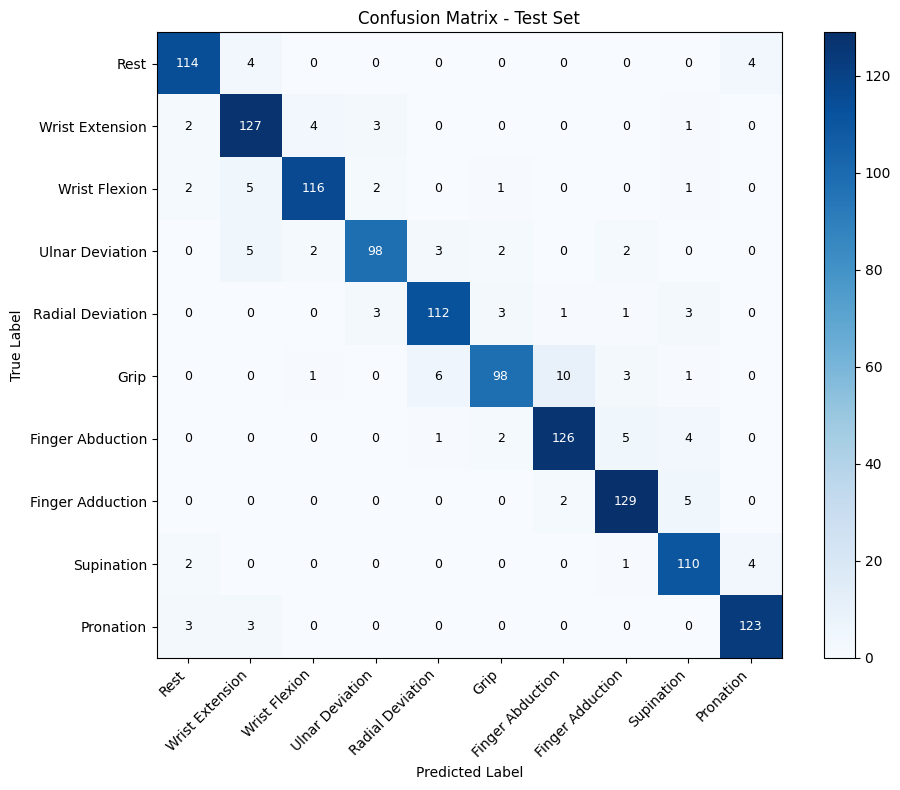

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "Rest",
    "Wrist Extension",
    "Wrist Flexion",
    "Ulnar Deviation",
    "Radial Deviation",
    "Grip",
    "Finger Abduction",
    "Finger Adduction",
    "Supination",
    "Pronation",
]

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

num_classes = NUM_CLASSES
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(all_targets, all_preds):
    cm[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.colorbar()

indices = np.arange(num_classes)
plt.xticks(indices, class_names, rotation=45, ha="right")
plt.yticks(indices, class_names)

threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=9,
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
